In [121]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [122]:
words = open('names.txt','r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [123]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [124]:
import random
random.seed(42)
random.shuffle(words)


In [125]:
block_size = 8
def build_dataset(words):
    X , Y =[],[]
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:]+ [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X ,Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xde,Yde = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [126]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x),'--->',itos[y.item()] )

........ ---> y
.......y ---> u
......yu ---> h
.....yuh ---> e
....yuhe ---> n
...yuhen ---> g
..yuheng ---> .
........ ---> d
.......d ---> i
......di ---> o
.....dio ---> n
....dion ---> d
...diond ---> r
..diondr ---> e
.diondre ---> .
........ ---> x
.......x ---> a
......xa ---> v
.....xav ---> i
....xavi ---> e


In [127]:
# class Linear:
#     def __init__(self,fan_in,fan_out,bias=True):
#         self.weight = torch.randn((fan_in,fan_out))/ fan_in**0.5
#         self.bias = torch.zeros(fan_out) if bias else None
#     def __call__(self,x):
#         self.out = x @ self.weight
#         if self.bias is not None:
#             self.out+=self.bias
#         return self.out
#     def parameters(self):
#         return [self.weight] + ([] if self.bias is None else [self.bias])
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):

        if self.training:
            if x.ndim == 2:
                dim =0
            elif x.ndim == 3:
                dim= (0,1)
            xmean = x.mean(dim,keepdim=True)
            xvar = x.var(dim,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self,num_embeddings,embedding_dim):
        self.weight = torch.randn((num_embeddings,embedding_dim))

    def __call__(self,IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

# class FlattenConsecutive:
#     def __init__(self,n):
#         self.n = n
#     def __call__(self,x):
#         B,T,C = x.shape
#         x = x.view(B,T//self.n,C*self.n)
#         if x.shape[1]==1:
#             x=x.squeeze(1)
#         self.out = x
#         return self.out
#     def parameters(self):
#         return []
class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

class Sequential:
    def __init__(self,layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [128]:
torch.manual_seed(42)

In [158]:
n_embd = 30 
n_hidden = 150

# C = torch.randn((vocab_size,n_embd))
model = Sequential([
          Embedding(vocab_size,n_embd),
          FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
          FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
          FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
          # FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
          Linear(n_hidden,vocab_size),
          ])
with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p  in parameters:
    p.requires_grad = True

104787


In [ ]:
max_steps= 200000
batch_size = 32
lossi = []
for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb , Yb = Xtr[ix],Ytr[ix]
    # forward pass
    # emb
    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb)
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update params
    lr = 0.1 if i<15000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad
    if i%10000 ==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break
        

      0/ 200000: 3.3947


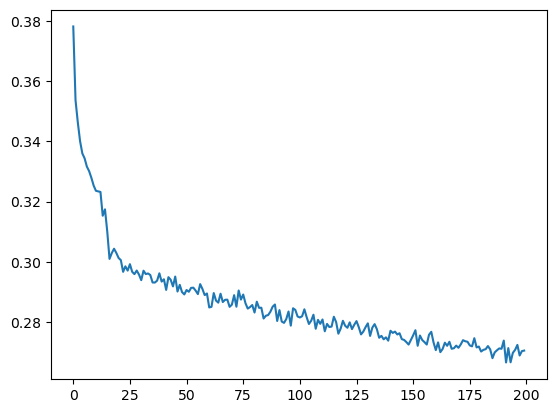

In [150]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [151]:
for layer in model.layers:#eval mode
    layer.training = None

In [152]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'dev':(Xde,Yde),
        'test':(Xte,Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('dev')
    

train 1.8389551639556885
dev 2.0048699378967285


In [153]:
# sample from model
for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        # forward pass
        
        logits = model(torch.tensor([context]))
        prob = F.softmax(logits,dim=1)
        # sample from distribution
        ix = torch.multinomial(prob , num_samples=1).item()
        #shift the context window
        context = context[1:]+[ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))
        

shadia.
zay.
dohnied.
nivin.
grett.
daniel.
lazell.
ritvi.
maveryl.
jadiah.
peni.
coden.
lailey.
navelis.
sedrael.
jou.
jaqueanya.
sinder.
xarielys.
aubriella.


In [141]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')